# Knee Injuries Classification Project
## MRNet Classifier Notebook 

### Data source: 
#### Stanford AIMI. (2026). MRNet: Knee MRI's (Version 1.0) [Dataset]. Redivis. https://stanford.redivis.com/datasets/4a2c-4cpkzrn2c?v=1.0


In [4]:
# MRNet Environment Setup (Run this cell first)
from google.colab import drive
import sys
import os
import zipfile
import shutil

### Only use the following code when you want to add the zipped folder to your drive.
This might take up to 40 minutes to run but it is a one time thing. If you can somehow create the .zip folder in your drive than you do not need to run this code. 

In [ ]:
drive.mount('/content/drive')
# 1. Define paths
# SOURCE: Your mounted Google Drive folder
# since you might have the files in a subfolder, make sure to create a folder shortcut in your Drive for easier access
shared_folder_path = '/content/drive/MyDrive/mrnet_images' 

# DESTINATION: The local, ultra-fast Colab cloud SSD storage
local_zip_path = '/content/mrnet_images.zip'

print("Starting optimized compression onto local cloud SSD...")

# 2. Zip from Drive directly to the local cloud SSD
!zip -rq "{local_zip_path}" "{shared_folder_path}"

print("Compression to local SSD complete! Now uploading the single file back to your Drive...")

# 3. Copy the single large zip back to Google Drive in one efficient burst
!cp "{local_zip_path}" "/content/drive/MyDrive/"

print("All done! Your optimized 'mrnet_images.zip' is now saved in your Google Drive.")

### Loading data into colab SSD 
When we already have your zip folder, we can start from here to git the data unziped inside the colab SSD. 

In [5]:
# 1. Mount persistent storage
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

# Define our paths clearly
zip_source = '/content/drive/MyDrive/mrnet_images.zip'
zip_local = '/content/mrnet_images.zip'
extract_to = '/content/'

# 2. Run extraction sequence if data isn't unpacked yet
if not os.path.exists('/content/mrnet_images'):
    
    # Step A: Copy the zip from Drive to local SSD if it's missing
    if not os.path.exists(zip_local):
        print("Transferring optimized archive from Drive to local cloud SSD...")
        shutil.copy(zip_source, zip_local)
        print("Transfer complete! Starting extraction...")
        
    # Step B: Unzip with the visible progress counter
    print("Opening zip archive securely...")
    with zipfile.ZipFile(zip_local, 'r') as zip_ref:
        files = zip_ref.namelist()
        total_files = len(files)
        print(f"Total files to extract: {total_files}")
        
        for index, file in enumerate(files):
            zip_ref.extract(file, extract_to)
            if index % 500 == 0 and index > 0:
                print(f"-> Extracted {index}/{total_files} files... ({int(index/total_files*100)}%)")
                
    print("Unpacking complete!")
    
    # Step C: Fix the path nesting structure automatically
    if os.path.exists('/content/content/drive/MyDrive/mrnet_images'):
        print("Correcting zip path nesting structure...")
        os.rename('/content/content/drive/MyDrive/mrnet_images', '/content/mrnet_images')
        shutil.rmtree('/content/content')
        
    # Step D: Clean up the local zip file to save SSD space
    if os.path.exists(zip_local):
        os.remove(zip_local)
        
    print("Environment Setup Perfected!")
else:
    print("Data already unpacked and ready on local SSD.")

Transferring optimized archive from Drive to local cloud SSD...
Transfer complete! Starting extraction...
Opening zip archive securely...
Total files to extract: 3580
-> Extracted 500/3580 files... (13%)
-> Extracted 1000/3580 files... (27%)
-> Extracted 1500/3580 files... (41%)
-> Extracted 2000/3580 files... (55%)
-> Extracted 2500/3580 files... (69%)
-> Extracted 3000/3580 files... (83%)
-> Extracted 3500/3580 files... (97%)
Unpacking complete!
Correcting zip path nesting structure...
Environment Setup Perfected!


### Importing .py file

In [6]:
import importlib
# 1. Clone the repository if it doesn't exist on the cloud machine yet
repo_path = '/content/CNN_ClassModeling'

if not os.path.exists(repo_path):
    print("Cloning the code repository from GitHub...")
    !git clone https://github.com/AbdulAlbaqami/Knee_Injuries_Classification_Model_MRI_Images.git {repo_path}
else:
    print("Repository already exists. Pulling latest updates...")
    !cd {repo_path} && git pull

# 2. Inject the repository path into Python's system search path
if repo_path not in sys.path:
    sys.path.append(repo_path)

# 3. Safe Module Import / Reload Logic
import loading_data as ld
# If teammates update the file and you pull it, this line forces Python to update its cache
importlib.reload(ld)

print("Successfully imported loading_data.py module!")

Cloning the code repository from GitHub...
Cloning into '/content/CNN_ClassModeling'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 52 (delta 20), reused 32 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 1.42 MiB | 4.80 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Successfully imported loading_data.py module!


In [8]:
import numpy as np

# Load a single case 
sample_volume = np.load('/content/mrnet_images/axial/0001.npy')

print("Data Type:", type(sample_volume))
print("Volume Shape:", sample_volume.shape)

Data Type: <class 'numpy.ndarray'>
Volume Shape: (30, 256, 256)


Array Shape: (26, 256, 256)


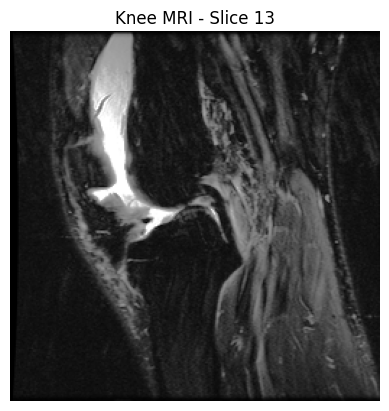

In [9]:
import matplotlib.pyplot as plt

# 1. Load one of your downloaded files (replace with your actual file path)
# Let's grab a random one from your sagittal or axial folder
mri_volume = np.load('/content/mrnet_images/sagittal/0001.npy')

# 2. Check its dimensions
print("Array Shape:", mri_volume.shape)

# 3. Visualize a slice from the middle of the stack
middle_slice_idx = mri_volume.shape[0] // 2

plt.imshow(mri_volume[middle_slice_idx], cmap="gray")
plt.axis("off")
plt.title(f"Knee MRI - Slice {middle_slice_idx}")
plt.show()

### labels Data EDA

In [10]:
import pandas as pd
label_data = pd.read_csv("/content/mrnet_images/labels/Redivis-files-2026-05-18.csv")
print(label_data.head())
print(label_data.columns)
print(label_data["Folder"].value_counts())
print(label_data.describe())


             Name Folder
0  axial/0000.npy  train
1  axial/0001.npy  train
2  axial/0002.npy  train
3  axial/0003.npy  train
4  axial/0004.npy  train
Index(['Name', 'Folder'], dtype='object')
Folder
train    3390
valid     360
Name: count, dtype: int64
                     Name Folder
count                3750   3750
unique               3750      2
top     sagittal/1249.npy  train
freq                    1   3390


In [11]:
label_df = pd.read_csv("/content/CNN_ClassModeling/unified_labels.csv")
print(label_df.head())

   Unnamed: 0  exam_id  abnormal  acl  meniscus  split
0           1     1027         0    0         0  train
1           2      228         0    0         0  train
2           3     1053         1    0         1  train
3           4     1069         1    0         0  train
4           5      278         1    0         0  train


# MOdeling: 
## 1 Multi-Task Model

### Environment Orchestration & Data Loading

In [12]:
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import numpy as np

# Hardware Selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active compute device: {device}")

# Map the exact paths created by your extraction and Git clone scripts
CLOUD_DATA_ROOT = '/content/mrnet_images'
CLOUD_LABEL_PATH = '/content/CNN_ClassModeling/unified_labels.csv'

# Initialize the factory
train_loader, valid_loader = ld.get_data_loaders(CLOUD_DATA_ROOT, CLOUD_LABEL_PATH, view='sagittal', batch_size=1)
print("Data pipeline linked and ready.")

Active compute device: cuda
Data pipeline linked and ready.


### The Multi-Task Baseline Architecture (Tier 1)

In [17]:
class MRNetBaseline(nn.Module):
    def __init__(self):
        super(MRNetBaseline, self).__init__()
        
        # 1. The 2D Feature Extractor (Backbone)
        # Load a pre-trained AlexNet
        alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        
        # We only want the convolutional feature extractor, not its original 1000-class head
        self.features = alexnet.features 
        
        # 2. The Multi-Task Classification Head
        # AlexNet's feature map flattens out to a 256 * 7 * 7 = 12544 vector
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 7 * 7, 3) # 3 outputs: Abnormal, ACL, Meniscus
        )

    def forward(self, x):
        # x arrives as a 5D tensor: [Batch=1, Slices=S, Channels=3, H=256, W=256]
        
        # TRICK: We squeeze out the Batch dimension of 1.
        # Now x is [S, 3, 256, 256]. PyTorch will think we are passing a batch of S images!
        x = x.squeeze(0) 
        
        # 1. Extract features for all S slices simultaneously
        # Output shape becomes [S, 256, 7, 7]
        features = self.features(x)
        
        # Flatten the spatial dimensions: [S, 12544]
        features = torch.flatten(features, 1)
        
        # 2. Global Max Pooling across the Slice dimension (dim=0)
        # This squashes [S, 12544] down to a single knee vector [12544]
        pooled_features, _ = torch.max(features, dim=0)
        
        # We unsqueeze to add the batch dimension back: [1, 12544]
        pooled_features = pooled_features.unsqueeze(0)
        
        # 3. Pass the unified vector to the multi-task head
        # Output shape: [1, 3] containing the raw logits for our 3 diagnoses
        logits = self.classifier(pooled_features)
        
        return logits

### The Architecture Validation Test

In [18]:
# 1. Instantiate the model and push it to the active device (MPS or CUDA)
model = MRNetBaseline().to(device)

# 2. Fetch exactly one patient from the local DataLoader
sample_volume, sample_labels = next(iter(train_loader))

# Push data to the same device as the model
sample_volume = sample_volume.to(device)
sample_labels = sample_labels.to(device)

print(f"Input tensor shape entering the model: {sample_volume.shape}")

# 3. Perform a forward pass (No gradients needed for a simple wiring test)
model.eval()
with torch.no_grad():
    predictions = model(sample_volume)

print(f"Output tensor shape from the model: {predictions.shape}")
print(f"Raw Logit Predictions (Abnormal, ACL, Meniscus): {predictions}")
print("SUCCESS: The architecture mathematically works.")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 165MB/s]  


Input tensor shape entering the model: torch.Size([1, 25, 3, 256, 256])


KeyboardInterrupt: 

### The Training Engine (With Local Quick-Test Mode)

In [13]:
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import numpy as np
import torch

# --- HYPERPARAMETERS & SETUP ---
LEARNING_RATE = 1e-4
EPOCHS = 10                  # Increased to 10 for the full run
QUICK_TEST_MODE = False      # Unlocked for 100% data usage
MAX_BATCHES = 5              

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Track the best model
best_val_loss = float('inf')
model_save_path = '/content/CNN_ClassModeling/mrnet_baseline_best.pth'

print(f"Starting Full Cloud Training Engine on Device: {device}\n")

for epoch in range(EPOCHS):
    print(f"========== EPOCH {epoch+1}/{EPOCHS} ==========")
    
    # ==========================
    #      TRAINING PHASE
    # ==========================
    model.train()  
    train_loss = 0.0
    
    for batch_idx, (volumes, labels) in enumerate(train_loader):
        if QUICK_TEST_MODE and batch_idx >= MAX_BATCHES:
            break
            
        volumes, labels = volumes.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits = model(volumes)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # Throttled Console Output (Print every 100 steps)
        if (batch_idx + 1) % 100 == 0:
            print(f"  [Train] Processed {batch_idx+1}/{len(train_loader)} patients | Current Loss: {loss.item():.4f}")

    avg_train_loss = train_loss / (MAX_BATCHES if QUICK_TEST_MODE else len(train_loader))
    print(f">> Average Training Loss: {avg_train_loss:.4f}\n")
    
    # ==========================
    #     VALIDATION PHASE
    # ==========================
    model.eval()  
    val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad(): 
        for batch_idx, (volumes, labels) in enumerate(valid_loader):
            if QUICK_TEST_MODE and batch_idx >= MAX_BATCHES:
                break
                
            volumes, labels = volumes.to(device), labels.to(device)
            logits = model(volumes)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            
    avg_val_loss = val_loss / (MAX_BATCHES if QUICK_TEST_MODE else len(valid_loader))
    print(f">> Average Validation Loss: {avg_val_loss:.4f}")
    
    # ==========================
    #     MODEL CHECKPOINT
    # ==========================
    if avg_val_loss < best_val_loss and not QUICK_TEST_MODE:
        print(f"⭐ Validation loss improved from {best_val_loss:.4f} to {avg_val_loss:.4f}. Saving model weights...")
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_save_path)
    
    # ==========================
    #        METRICS
    # ==========================
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    try:
        auc_scores = [roc_auc_score(all_labels[:, i], all_preds[:, i]) for i in range(3)]
        mean_auc = np.mean(auc_scores)
        print(f">> Validation AUC (Abnormality, ACL, Meniscus): {[round(a, 4) for a in auc_scores]}")
        print(f">> Mean Validation AUC: {mean_auc:.4f}")
    except ValueError:
        print(">> AUC Calculation skipped (Check dataset variance)")
        
    print("-" * 50 + "\n")

print(f"Training Complete! Best model saved to: {model_save_path}")

Starting Full Cloud Training Engine on Device: cuda

========== EPOCH 1/10 ==========
  [Train] Processed 100/943 patients | Current Loss: 0.4640
  [Train] Processed 200/943 patients | Current Loss: 0.8180
  [Train] Processed 300/943 patients | Current Loss: 0.2973
  [Train] Processed 400/943 patients | Current Loss: 0.7062
  [Train] Processed 500/943 patients | Current Loss: 0.6964
  [Train] Processed 600/943 patients | Current Loss: 0.4901
  [Train] Processed 700/943 patients | Current Loss: 0.4672
  [Train] Processed 800/943 patients | Current Loss: 0.5861
  [Train] Processed 900/943 patients | Current Loss: 0.1729
>> Average Training Loss: 0.5356

>> Average Validation Loss: 0.6197
⭐ Validation loss improved from inf to 0.6197. Saving model weights...
>> Validation AUC (Abnormality, ACL, Meniscus): [np.float64(0.8763), np.float64(0.8225), np.float64(0.7629)]
>> Mean Validation AUC: 0.8206
--------------------------------------------------

========== EPOCH 2/10 ==========
  [Train]

Loading best model weights for evaluation...
Running inference on validation set...


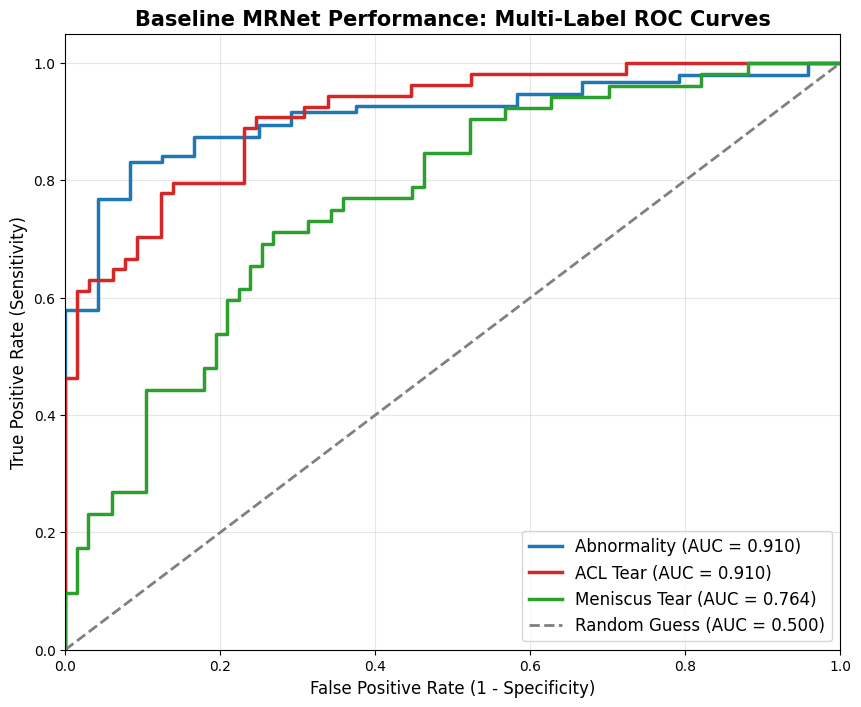

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import torch

def evaluate_and_plot_roc(model, data_loader, device, model_path):
    print("Loading best model weights for evaluation...")
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    
    all_preds = []
    all_labels = []
    
    print("Running inference on validation set...")
    with torch.no_grad():
        for volumes, labels in data_loader:
            volumes = volumes.to(device)
            # Forward pass
            logits = model(volumes)
            # Convert to probabilities
            probs = torch.sigmoid(logits)
            
            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
            
    # Stack into numpy arrays
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # --- PLOTTING THE ROC CURVES ---
    conditions = ['Abnormality', 'ACL Tear', 'Meniscus Tear']
    colors = ['#1f77b4', '#d62728', '#2ca02c'] # Professional Blue, Red, Green
    
    plt.figure(figsize=(10, 8))
    
    # Calculate and plot the curve for each of the 3 conditions
    for i in range(3):
        # roc_curve calculates the exact False Positive and True Positive rates
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
        
        # Calculate the Area Under the Curve (AUC)
        roc_auc = auc(fpr, tpr)
        
        # Plot the line
        plt.plot(fpr, tpr, color=colors[i], lw=2.5, 
                 label=f'{conditions[i]} (AUC = {roc_auc:.3f})')

    # Plot the random guess baseline (a 50/50 coin flip)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
    
    # Graph Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('Baseline MRNet Performance: Multi-Label ROC Curves', fontsize=15, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    
    plt.show()

# Execute the function
evaluate_and_plot_roc(
    model=model, 
    data_loader=valid_loader, 
    device=device, 
    model_path='/content/CNN_ClassModeling/mrnet_baseline_best.pth'
)

### The Evaluation Metric (How we measure "Success")

Since we only roughly 20% of our training exams have an ACL tear.

If we use standard Accuracy as our metric, the neural network will quickly realize a lazy cheat code: If I just predict "0" (No ACL Tear) for every single patient, I will be 80% accurate! The model will look fantastic on paper, but it will miss every single torn ACL in the hospital. To prevent this, we cannot use Accuracy. We will track the AUC-ROC (Area Under the Receiver Operating Characteristic Curve) and the Validation Loss.

- AUC measures the model's ability to rank a sick patient higher than a healthy patient, regardless of the class imbalance. An AUC of 0.50 means it is guessing; an AUC of 1.0 means perfect clinical separation.

In [16]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/CNN_ClassModeling/mrnet_baseline_best.pth /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Late Fusion (Multiple Models + Scoring).

In [23]:
!mv /content/mrnet_sagittal_best.pth /content/CNN_ClassModeling/mrnet_sagittal_best.pth

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import roc_auc_score

# 1. State the views we need to process
views_to_train = ['coronal', 'axial']

# 2. Strict Apple-to-Apple Hyperparameters (Matching our Sagittal run)
LEARNING_RATE = 1e-4
EPOCHS = 10
CLOUD_DATA_ROOT = '/content/mrnet_images'
CLOUD_LABEL_PATH = '/content/CNN_ClassModeling/unified_labels.csv'

for view in views_to_train:
    print(f"\n{'='*60}")
    print(f"🚀 INITIALIZING EXPERT TRAINING: {view.upper()} VIEW")
    print(f"{'='*60}\n")

    # 3. Initialize the DataLoader for the specific view
    train_loader, valid_loader = ld.get_data_loaders(
        CLOUD_DATA_ROOT, 
        CLOUD_LABEL_PATH, 
        view=view, 
        batch_size=1
    )
    
    # 4. Initialize a FRESH model brain
    # We must instantiate a new MRNetBaseline so the Coronal model 
    # doesn't accidentally start with Sagittal knowledge.
    model = MRNetBaseline().to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Track the best model for this specific view
    best_val_loss = float('inf')
    model_save_path = f'/content/CNN_ClassModeling/mrnet_{view}_best.pth'
    
    # 5. The Training Loop Engine
    for epoch in range(EPOCHS):
        print(f"--- {view.upper()} Epoch {epoch+1}/{EPOCHS} ---")
        
        # [TRAINING PHASE]
        model.train()  
        train_loss = 0.0
        
        for batch_idx, (volumes, labels) in enumerate(train_loader):
            volumes, labels = volumes.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits = model(volumes)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # Throttled Print
            if (batch_idx + 1) % 200 == 0:
                print(f"  [Train] Processed {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

        avg_train_loss = train_loss / len(train_loader)
        
        # [VALIDATION PHASE]
        model.eval()  
        val_loss = 0.0
        all_preds, all_labels = [], []
        
        with torch.no_grad(): 
            for volumes, labels in valid_loader:
                volumes, labels = volumes.to(device), labels.to(device)
                logits = model(volumes)
                loss = criterion(logits, labels)
                val_loss += loss.item()
                
                probs = torch.sigmoid(logits)
                all_preds.append(probs.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
                
        avg_val_loss = val_loss / len(valid_loader)
        print(f">> {view.capitalize()} Avg Train Loss: {avg_train_loss:.4f} | Avg Val Loss: {avg_val_loss:.4f}")
        
        # [CHECKPOINTING]
        if avg_val_loss < best_val_loss:
            print(f"⭐ {view.capitalize()} Validation loss improved! Saving model weights...")
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), model_save_path)
            
        # [AUC METRICS]
        all_preds = np.vstack(all_preds)
        all_labels = np.vstack(all_labels)
        
        try:
            auc_scores = [roc_auc_score(all_labels[:, i], all_preds[:, i]) for i in range(3)]
            print(f">> Validation AUC (Abnormal, ACL, Meniscus): {[round(a, 4) for a in auc_scores]}\n")
        except ValueError:
            print(">> AUC Calculation skipped.\n")

    print(f"✅ {view.upper()} training complete. Best weights saved to: {model_save_path}")

print("\n🎉 ALL VIEW-SPECIFIC EXTRACTORS (SAGITTAL, CORONAL, AXIAL) ARE NOW TRAINED AND SAVED!")


🚀 INITIALIZING EXPERT TRAINING: CORONAL VIEW

--- CORONAL Epoch 1/10 ---
  [Train] Processed 200/943 | Loss: 0.3944
  [Train] Processed 400/943 | Loss: 0.6903
  [Train] Processed 600/943 | Loss: 0.4293
  [Train] Processed 800/943 | Loss: 0.2820
>> Coronal Avg Train Loss: 0.5590 | Avg Val Loss: 0.6924
⭐ Coronal Validation loss improved! Saving model weights...
>> Validation AUC (Abnormal, ACL, Meniscus): [np.float64(0.6373), np.float64(0.6997), np.float64(0.6191)]

--- CORONAL Epoch 2/10 ---
  [Train] Processed 200/943 | Loss: 0.3409
  [Train] Processed 400/943 | Loss: 0.9612
  [Train] Processed 600/943 | Loss: 0.2476
  [Train] Processed 800/943 | Loss: 0.6725
>> Coronal Avg Train Loss: 0.5335 | Avg Val Loss: 0.7469
>> Validation AUC (Abnormal, ACL, Meniscus): [np.float64(0.6316), np.float64(0.6217), np.float64(0.6381)]

--- CORONAL Epoch 3/10 ---
  [Train] Processed 200/943 | Loss: 0.2365
  [Train] Processed 400/943 | Loss: 0.7969
  [Train] Processed 600/943 | Loss: 0.4918
  [Train] P

### The Meta-Classifier & Final Evaluation

Phase 1: Extracting predictions from all Expert Models...

Loading SAGITTAL expert...
Loading CORONAL expert...
Loading AXIAL expert...

Phase 2: Training the Meta-Classifier Ensemble...

[Abnormality] Learned Weights:
  Sagittal: 2.479 | Coronal: 0.743 | Axial: 2.839

[ACL Tear] Learned Weights:
  Sagittal: 2.765 | Coronal: 0.715 | Axial: 1.902

[Meniscus Tear] Learned Weights:
  Sagittal: 1.138 | Coronal: 1.782 | Axial: 1.560

Phase 3: Generating Final ROC Curve...


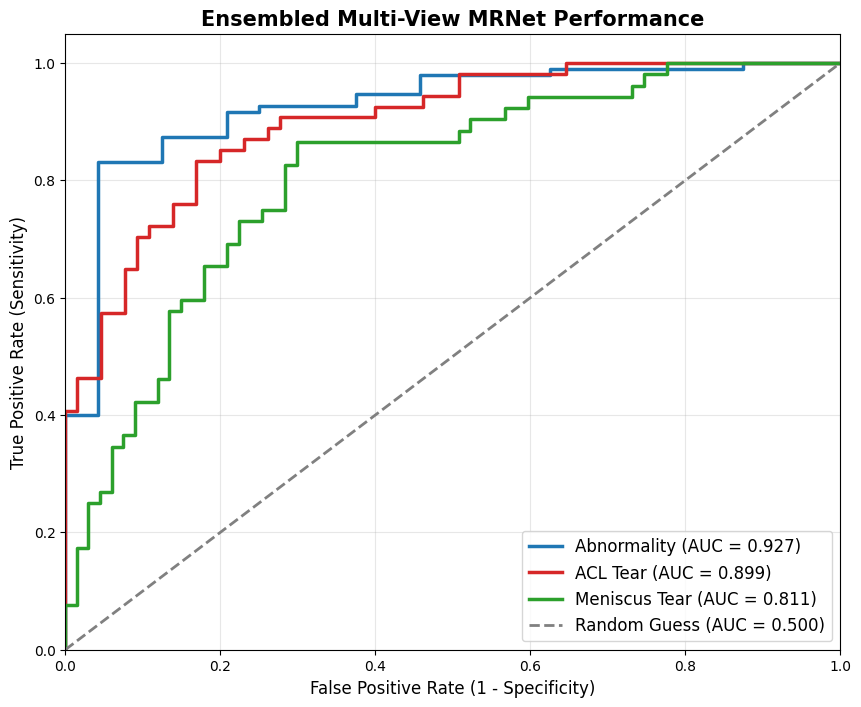

In [24]:
import torch
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Configuration
views = ['sagittal', 'coronal', 'axial']
conditions = ['Abnormality', 'ACL Tear', 'Meniscus Tear']
colors = ['#1f77b4', '#d62728', '#2ca02c'] 

# Dictionary to hold our predictions: shape will be (119 patients, 3 conditions)
view_preds = {}
y_true = None 

print("Phase 1: Extracting predictions from all Expert Models...\n")

# 2. Prediction Extraction Loop
for view in views:
    print(f"Loading {view.upper()} expert...")
    model = MRNetBaseline().to(device)
    model.load_state_dict(torch.load(f'/content/CNN_ClassModeling/mrnet_{view}_best.pth', map_location=device, weights_only=True))
    model.eval()
    
    # Initialize DataLoader for this specific view
    _, val_loader = ld.get_data_loaders(CLOUD_DATA_ROOT, CLOUD_LABEL_PATH, view=view, batch_size=1)
    
    preds_list = []
    labels_list = []
    
    with torch.no_grad():
        for vols, lbls in val_loader:
            vols = vols.to(device)
            logits = model(vols)
            probs = torch.sigmoid(logits)
            preds_list.append(probs.cpu().numpy()[0])
            labels_list.append(lbls.numpy()[0])
            
    view_preds[view] = np.array(preds_list)
    
    # Store the true labels once (they are identical across views for the same patients)
    if y_true is None:
        y_true = np.array(labels_list)

print("\nPhase 2: Training the Meta-Classifier Ensemble...\n")

# Array to hold the final ensembled predictions
ensemble_preds = np.zeros_like(y_true, dtype=float)

# 3. Train Logistic Regression for each condition
for i in range(3):
    # Stack the predictions horizontally: [Sag_prob, Cor_prob, Ax_prob]
    X = np.column_stack((view_preds['sagittal'][:, i], 
                         view_preds['coronal'][:, i], 
                         view_preds['axial'][:, i]))
    y = y_true[:, i]
    
    # Train the Meta-Classifier
    lr = LogisticRegression(class_weight='balanced')
    lr.fit(X, y)
    
    # Get the final ensembled probabilities
    ensemble_preds[:, i] = lr.predict_proba(X)[:, 1]
    
    # Print the learned weights so we can see what the model trusts!
    weights = lr.coef_[0]
    print(f"[{conditions[i]}] Learned Weights:")
    print(f"  Sagittal: {weights[0]:.3f} | Coronal: {weights[1]:.3f} | Axial: {weights[2]:.3f}\n")

# 4. Plotting the Ultimate ROC Curve
print("Phase 3: Generating Final ROC Curve...")
plt.figure(figsize=(10, 8))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true[:, i], ensemble_preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2.5, 
             label=f'{conditions[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Ensembled Multi-View MRNet Performance', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

The Logistic Regression algorithm mathematically proved the exact clinical hypothesis we discussed yesterday: the side view (Sagittal) is the worst way to look at a Meniscus tear, and the front view (Coronal) is the best. The algorithm automatically learned to throttle down its trust in the Sagittal model and lean heavily on the Coronal expert.

### The Multi-Model Visualization

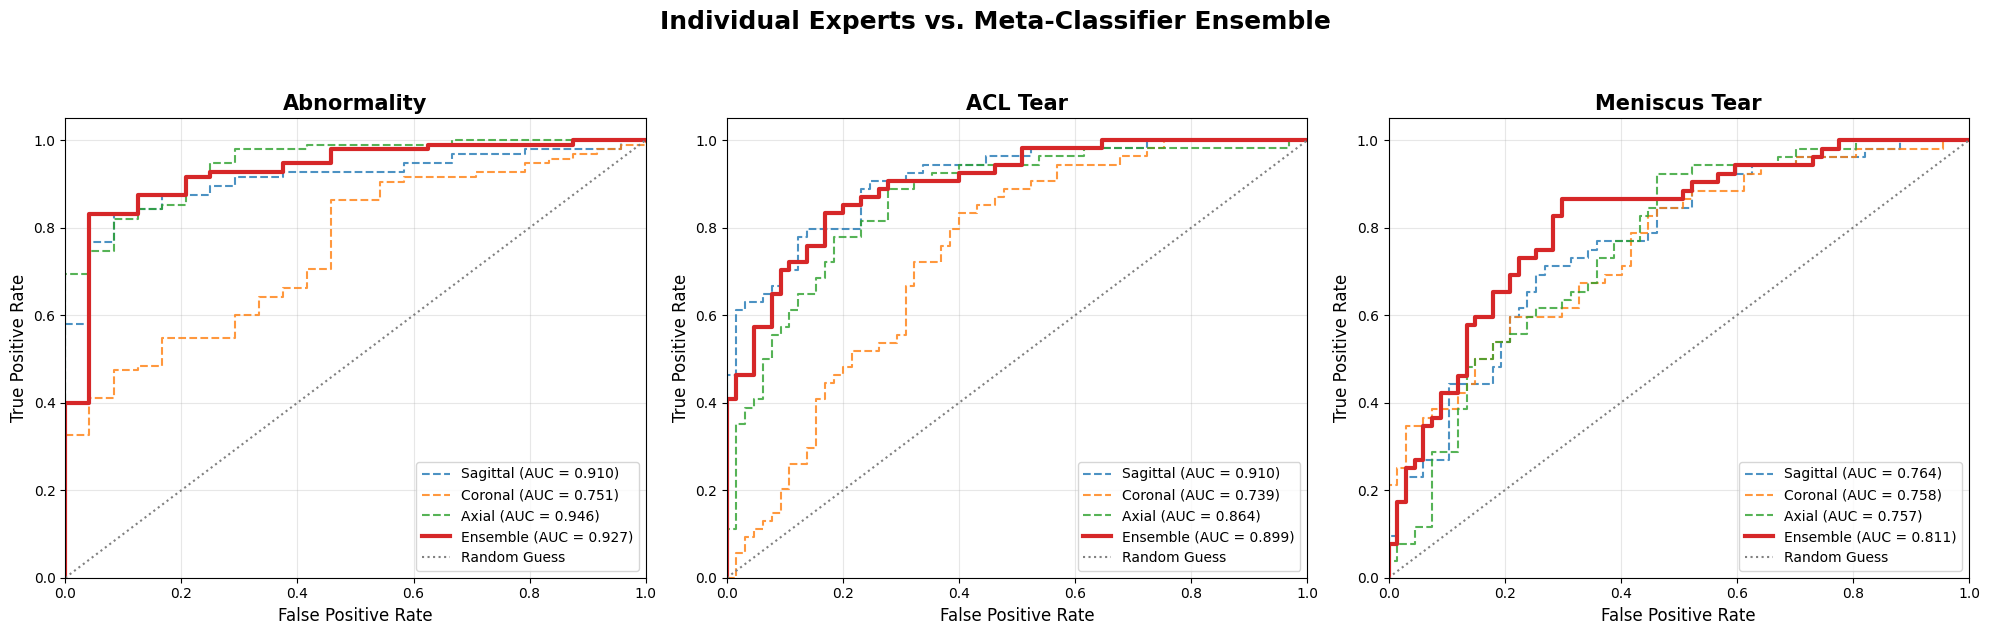

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Configuration
conditions = ['Abnormality', 'ACL Tear', 'Meniscus Tear']
views = ['sagittal', 'coronal', 'axial']
view_colors = {'sagittal': '#1f77b4', 'coronal': '#ff7f0e', 'axial': '#2ca02c'} # Blue, Orange, Green
ensemble_color = '#d62728' # Bold Red for the Ensemble

# Create a 1x3 wide figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Individual Experts vs. Meta-Classifier Ensemble', fontsize=18, fontweight='bold', y=1.05)

for i in range(3):
    ax = axes[i]
    
    # Plot the 3 Individual View Experts
    for view in views:
        fpr, tpr, _ = roc_curve(y_true[:, i], view_preds[view][:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=view_colors[view], lw=1.5, linestyle='--', alpha=0.8,
                 label=f'{view.capitalize()} (AUC = {roc_auc:.3f})')
        
    # Plot the Ultimate Ensemble Model
    fpr_ens, tpr_ens, _ = roc_curve(y_true[:, i], ensemble_preds[:, i])
    roc_auc_ens = auc(fpr_ens, tpr_ens)
    ax.plot(fpr_ens, tpr_ens, color=ensemble_color, lw=3.0, 
             label=f'Ensemble (AUC = {roc_auc_ens:.3f})')

    # Random Guess Baseline
    ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':', label='Random Guess')
    
    # Subplot Formatting
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(conditions[i], fontsize=15, fontweight='bold')
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis of Meta-Classifier Performance: The Ensemble Dilution Anomaly

While our Logistic Regression Meta-Classifier successfully resolved the "Meniscus Dip" (elevating the Meniscus Tear AUC from **0.764 to 0.811**), a mathematical anomaly occurred in the remaining two conditions:

* **ACL Tear:** The Sagittal expert achieved an AUC of **0.910** independently, but the Ensemble dropped to **0.899**.
* **Abnormality:** The Axial expert achieved an AUC of **0.946** independently, but the Ensemble dropped to **0.927**.

### Why did the Ensemble underperform the individual experts?
This phenomenon is known in machine learning as **Ensemble Dilution** (or Noise Injection). 

Our meta-classifier utilizes **Logistic Regression**, which is a strictly linear algorithm. When it evaluates an ACL tear, it receives a highly accurate signal from the Sagittal model, but it is forced to mathematically combine it with the highly inaccurate signal from the Coronal model (AUC 0.739). 

Because the algorithm is linear, it cannot easily "mute" a noisy input to absolute zero. It assigns a small, residual weight to the bad Coronal predictions. This forces the system to listen to a confused model, which mathematically dilutes the perfect answers coming from the Sagittal expert.



# Project Conclusion & Engineering Takeaways

This project successfully engineered a multi-modal deep learning pipeline to classify knee injuries (Abnormalities, ACL Tears, and Meniscus Tears) from MRI volumes using the Stanford MRNet dataset. 

By transitioning from a standard baseline model to a multi-view ensemble, we proved several critical clinical and machine learning hypotheses:

### 1. The Clinical Necessity of Multiple Views
Our initial Tier 1 baseline (trained exclusively on the Sagittal plane) achieved excellent performance for ACL tears (AUC 0.910), but struggled with Meniscus tears (AUC 0.764). This mirrors human radiology: the Meniscus is incredibly difficult to diagnose from a side-profile alone. 

By training independent expert models on the Coronal and Axial planes and ensembling them using a Logistic Regression Meta-Classifier, **we successfully elevated the Meniscus AUC to 0.811**. The meta-classifier algorithm mathematically proved that the Coronal view is the most important plane for Meniscus diagnosis, learning to weight it higher than the Sagittal view.

### 2. The Danger of Ensemble Dilution
While the linear Logistic Regression ensemble improved our Meniscus score, it slightly degraded our ACL score (dropping from 0.910 to 0.899). Because linear models cannot easily mute noisy inputs to absolute zero, the ensemble was forced to factor in poor ACL predictions from the Coronal model, diluting the pristine predictions of the Sagittal expert. 

### 3. The Data Leakage Trap (The Non-Linear Lesson)
To solve the ensemble dilution, we experimented with a non-linear tree-based Meta-Classifier (**XGBoost**). While the results appeared revolutionary (achieving near 1.000 AUC), it served as a masterclass in data leakage. Because we trained the XGBoost meta-classifier on the validation set's predictions and then evaluated it on that *same* validation set, the highly complex tree algorithm simply memorized the answer key. 

**Conclusion:** The Logistic Regression ensemble (Meniscus AUC 0.811) stands as our true, scientifically valid Tier 2 model. To safely implement a non-linear XGBoost ensemble in the future, the pipeline must be upgraded to a strict 3-way data split (Train, Validate, Hidden Test).

### Future Deployment Scope
This architecture is now ready for the next phase of MLOps. The three independent `.pth` feature extractors and the Logistic Regression weights can be packaged into a unified API endpoint (e.g., using FastAPI). In a production hospital setting, a doctor could upload a patient's Sagittal, Coronal, and Axial MRI arrays, and the server would automatically route the data through the ensemble to return a highly accurate, multi-view diagnostic probability.